# 📊 Cryptocurrency Market Analysis Project

This notebook is a refactored finance project focused on **cryptocurrencies** instead of bank stocks.

We will analyze crypto price behavior using `yfinance`, `pandas`, `numpy`, `seaborn`, `matplotlib`, and `plotly`.

### Main goals

- Download historical crypto market data
- Clean and reshape the dataset
- Analyze closing prices, returns, volatility, correlation, and risk
- Visualize crypto trends using static and interactive charts
- Compare cryptocurrencies using data science techniques

## 0. Install Needed Libraries

Run this cell only if the libraries are missing.

In [ ]:
# !pip install yfinance pandas numpy matplotlib seaborn plotly nbformat

## 1. Imports and Setup

### Request
Import the libraries needed for data analysis and visualization.

### Short explanation
We use `pandas` and `numpy` for data manipulation, `yfinance` for downloading financial data, and `plotly`/`seaborn`/`matplotlib` for visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import yfinance as yf


## 2. Download Cryptocurrency Data

### Request
Download historical market data for several cryptocurrencies.

### Short explanation
Each crypto has daily market data such as Open, High, Low, Close, Adj Close, and Volume. We use USD pairs because they are easier to compare.

In [12]:
tickers = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "DOGE-USD", "ADA-USD"]

start_date = "2020-01-01"
end_date = "2026-05-01"

crypto_data = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    group_by="ticker"
)

crypto_data.head()

[*********************100%***********************]  6 of 6 completed


Ticker       ADA-USD                                              BTC-USD  \
Price           Open      High       Low     Close    Volume         Open   
Date                                                                        
2020-01-01  0.032832  0.033813  0.032704  0.033458  22948374  7194.892090   
2020-01-02  0.033474  0.033507  0.032448  0.032751  20843934  7202.551270   
2020-01-03  0.032748  0.034427  0.032491  0.034180  30162644  6984.428711   
2020-01-04  0.034191  0.034685  0.033872  0.034595  29535781  7345.375488   
2020-01-05  0.034574  0.035356  0.034545  0.034721  21479178  7410.451660   

Ticker                                                          ...  \
Price              High          Low        Close       Volume  ...   
Date                                                            ...   
2020-01-01  7254.330566  7174.944336  7200.174316  18565664997  ...   
2020-01-02  7212.155273  6935.270020  6985.470215  20802083465  ...   
2020-01-03  7413.715332  6914.996094  7344.884277  28111481032  ...   
2020-01-04  7427.385742  7309.514160  7410.656738  18444271275  ...   
2020-01-05  7544.497070  7400.535645  7411.317383  19725074095  ...   

Ticker         ETH-USD                                                   \
Price             Open        High         Low       Close       Volume   
Date                                                                      
2020-01-01  129.630661  132.835358  129.198288  130.802002   7935230330   
2020-01-02  130.820038  130.820038  126.954910  127.410179   8032709256   
2020-01-03  127.411263  134.554016  126.490021  134.171707  10476845358   
2020-01-04  134.168518  136.052719  133.040558  135.069366   7430904515   
2020-01-05  135.072098  139.410202  135.045624  136.276779   7526675353   

Ticker      DOGE-USD                                          
Price           Open      High       Low     Close    Volume  
Date                                                          
2020-01-01  0.002028  0.002052  0.002021  0.002033  51180941  
2020-01-02  0.002034  0.002110  0.001983  0.002009  65071106  
2020-01-03  0.002008  0.002177  0.001991  0.002145  62619988  
2020-01-04  0.002144  0.002490  0.002050  0.002241  94227582  
2020-01-05  0.002240  0.002491  0.002117  0.002419  52631740  

[5 rows x 30 columns]

## 3. Basic Data Overview

### Request
Check the structure, shape, columns, dates, and missing values of the downloaded dataset.

### Short explanation
Before analysis, we need to understand what the dataset contains and whether there are missing values or unusual structure.

In [13]:
print("Dataset shape:", crypto_data.shape)
print("Date range:", crypto_data.index.min(), "to", crypto_data.index.max())
print("Number of tickers:", len(tickers))

crypto_data.info()

Dataset shape: (2312, 30)
Date range: 2020-01-01 00:00:00 to 2026-04-30 00:00:00
Number of tickers: 6
<class 'pandas.DataFrame'>
DatetimeIndex: 2312 entries, 2020-01-01 to 2026-04-30
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (ADA-USD, Open)     2312 non-null   float64
 1   (ADA-USD, High)     2312 non-null   float64
 2   (ADA-USD, Low)      2312 non-null   float64
 3   (ADA-USD, Close)    2312 non-null   float64
 4   (ADA-USD, Volume)   2312 non-null   int64  
 5   (BTC-USD, Open)     2312 non-null   float64
 6   (BTC-USD, High)     2312 non-null   float64
 7   (BTC-USD, Low)      2312 non-null   float64
 8   (BTC-USD, Close)    2312 non-null   float64
 9   (BTC-USD, Volume)   2312 non-null   int64  
 10  (XRP-USD, Open)     2312 non-null   float64
 11  (XRP-USD, High)     2312 non-null   float64
 12  (XRP-USD, Low)      2312 non-null   float64
 13  (XRP-USD, Close)    2312 non-null   float64


In [14]:
crypto_data.columns

MultiIndex([( 'ADA-USD',   'Open'),
            ( 'ADA-USD',   'High'),
            ( 'ADA-USD',    'Low'),
            ( 'ADA-USD',  'Close'),
            ( 'ADA-USD', 'Volume'),
            ( 'BTC-USD',   'Open'),
            ( 'BTC-USD',   'High'),
            ( 'BTC-USD',    'Low'),
            ( 'BTC-USD',  'Close'),
            ( 'BTC-USD', 'Volume'),
            ( 'XRP-USD',   'Open'),
            ( 'XRP-USD',   'High'),
            ( 'XRP-USD',    'Low'),
            ( 'XRP-USD',  'Close'),
            ( 'XRP-USD', 'Volume'),
            ( 'BNB-USD',   'Open'),
            ( 'BNB-USD',   'High'),
            ( 'BNB-USD',    'Low'),
            ( 'BNB-USD',  'Close'),
            ( 'BNB-USD', 'Volume'),
            ( 'ETH-USD',   'Open'),
            ( 'ETH-USD',   'High'),
            ( 'ETH-USD',    'Low'),
            ( 'ETH-USD',  'Close'),
            ( 'ETH-USD', 'Volume'),
            ('DOGE-USD',   'Open'),
            ('DOGE-USD',   'High'),
            ('DOGE-USD',    

In [15]:
crypto_data.isna().sum().sort_values(ascending=False).head(20)

Ticker   Price 
ADA-USD  Open      0
         High      0
         Low       0
         Close     0
         Volume    0
BTC-USD  Open      0
         High      0
         Low       0
         Close     0
         Volume    0
XRP-USD  Open      0
         High      0
         Low       0
         Close     0
         Volume    0
BNB-USD  Open      0
         High      0
         Low       0
         Close     0
         Volume    0
dtype: int64

## 4. Create Separate DataFrames for Close Price and Volume

### Request
Create one DataFrame for closing prices and one DataFrame for trading volume.

### Short explanation
Most analysis uses the closing price because it represents the final daily market value. Volume helps us understand trading activity.

In [16]:

close_prices = crypto_data.xs("Close", axis=1, level=1)
volume = crypto_data.xs("Volume", axis=1, level=1)

close_prices.head()

Ticker,ADA-USD,BTC-USD,XRP-USD,BNB-USD,ETH-USD,DOGE-USD
Date,,,,,,
2020-01-01,0.033458,7200.174316,0.192667,13.689083,130.802002,0.002033
2020-01-02,0.032751,6985.470215,0.188043,13.027011,127.410179,0.002009
2020-01-03,0.034180,7344.884277,0.193521,13.660452,134.171707,0.002145
2020-01-04,0.034595,7410.656738,0.194355,13.891512,135.069366,0.002241
2020-01-05,0.034721,7411.317383,0.195537,14.111019,136.276779,0.002419


In [17]:
volume.head()

Ticker,ADA-USD,BTC-USD,XRP-USD,BNB-USD,ETH-USD,DOGE-USD
Date,,,,,,
2020-01-01,22948374,18565664997,1041134003,172980718,7935230330,51180941
2020-01-02,20843934,20802083465,1085351426,156376427,8032709256,65071106
2020-01-03,30162644,28111481032,1270017043,173683857,10476845358,62619988
2020-01-04,29535781,18444271275,999331594,182230374,7430904515,94227582
2020-01-05,21479178,19725074095,1168067557,202552703,7526675353,52631740


## 5. Clean the Close Price Data

### Request
Check and handle missing values in the closing price DataFrame.

### Short explanation
Some cryptos may have missing values because they were listed later or because data is unavailable for some dates. Forward filling uses the previous valid price when needed.

In [18]:
close_prices.isna().sum().sort_values(ascending=False)

Ticker
ADA-USD     0
BTC-USD     0
XRP-USD     0
BNB-USD     0
ETH-USD     0
DOGE-USD    0
dtype: int64

In [19]:
# read more for forward filling function
# we did not have null values, so in our case it does nothing

close_prices_clean = close_prices.ffill()

close_prices_clean.isna().sum().sort_values(ascending=False)

Ticker
ADA-USD     0
BTC-USD     0
XRP-USD     0
BNB-USD     0
ETH-USD     0
DOGE-USD    0
dtype: int64

## 6. Maximum and Minimum Closing Price for Each Crypto

### Request
Find the maximum and minimum closing price for each cryptocurrency.

### Short explanation
This gives a quick overview of the highest and lowest price each crypto reached during the selected period.

In [20]:
price_summary = pd.DataFrame({
    "Min Close": close_prices_clean.min(),
    "Max Close": close_prices_clean.max(),
    "Mean Close": close_prices_clean.mean(),
    "Last Close": close_prices_clean.iloc[-1]
})

price_summary.sort_values("Max Close", ascending=False)

,Min Close,Max Close,Mean Close,Last Close
Ticker,,,,
BTC-USD,4970.788086,124752.531250,48680.178754,76304.320312
ETH-USD,110.605873,4831.348633,2173.487195,2256.251221
BNB-USD,9.386050,1310.214355,400.591054,615.066711
XRP-USD,0.139635,3.555765,0.931095,1.367430
ADA-USD,0.023961,2.968239,0.617933,0.246180
DOGE-USD,0.001537,0.684777,0.124464,0.106493


## 7. Plot Closing Prices Over Time

### Request
Visualize the closing price trend of all cryptocurrencies.

### Short explanation
Line charts help us see long-term movement, crashes, recoveries, and strong growth periods.

In [21]:
fig = px.line(
    close_prices_clean,
    x=close_prices_clean.index,
    y=close_prices_clean.columns,
    title="Cryptocurrency Closing Prices Over Time",
    labels={"value": "Close Price (USD)", "Date": "Date", "variable": "Crypto"}
)
fig.show()

## 8. Normalize Prices to Compare Growth

### Request
Normalize all prices so every crypto starts at 1.

### Short explanation
Cryptos have very different price levels. Normalization lets us compare percentage growth instead of raw price.

In [22]:
normalized_prices = close_prices_clean / close_prices_clean.iloc[0]

fig = px.line(
    normalized_prices,
    x=normalized_prices.index,
    y=normalized_prices.columns,
    title="Normalized Crypto Prices: Growth Compared From First Day",
    labels={"value": "Normalized Price", "Date": "Date", "variable": "Crypto"}
)
fig.show()

## 9. Create Daily Returns DataFrame

### Request
Calculate daily percentage returns for each crypto.

### Short explanation
Returns show how much the price changed from one day to the next. This is more useful than raw price when analyzing risk and volatility.

$$r_t = \frac{p_t}{p_{t-1}} - 1$$

In [23]:
returns = close_prices_clean.pct_change().dropna(how="all")

returns.head()

Ticker,ADA-USD,BTC-USD,XRP-USD,BNB-USD,ETH-USD,DOGE-USD
Date,,,,,,
2020-01-02,-0.021131,-0.029819,-0.024000,-0.048365,-0.025931,-0.011805
2020-01-03,0.043632,0.051452,0.029132,0.048625,0.053069,0.067695
2020-01-04,0.012142,0.008955,0.004310,0.016915,0.006690,0.044755
2020-01-05,0.003642,0.000089,0.006082,0.015802,0.008939,0.079429
2020-01-06,0.073471,0.048291,0.132829,0.060009,0.058905,0.018189


## 10. Best and Worst Single-Day Returns

### Request
Find the best and worst daily return for each crypto, including the date.

### Short explanation
Crypto can move sharply in one day. This analysis identifies the largest daily jumps and drops.

In [24]:
best_worst = pd.DataFrame({
    "Best Day": returns.idxmax(),
    "Best Return": returns.max(),
    "Worst Day": returns.idxmin(),
    "Worst Return": returns.min()
})

best_worst.sort_values("Best Return", ascending=False)

,Best Day,Best Return,Worst Day,Worst Return
Ticker,,,,
DOGE-USD,2021-01-28,3.555466,2021-01-30,-0.402570
XRP-USD,2023-07-13,0.730750,2020-12-23,-0.423340
ADA-USD,2025-03-02,0.713276,2020-03-12,-0.395672
BNB-USD,2021-02-19,0.697604,2020-03-12,-0.419046
ETH-USD,2021-01-03,0.259475,2020-03-12,-0.423472
BTC-USD,2021-02-08,0.187465,2020-03-12,-0.371695


## 11. Risk Analysis Using Volatility

### Request
Calculate daily volatility and annualized volatility for each cryptocurrency.

### Short explanation
Volatility measures how much returns fluctuate. Higher volatility means higher risk and larger price swings.

In [25]:
risk_summary = pd.DataFrame({
    "Daily Volatility": returns.std(),
    "Annualized Volatility": returns.std() * np.sqrt(365),
    "Average Daily Return": returns.mean(),
    "Annualized Return Estimate": returns.mean() * 365
})

risk_summary.sort_values("Annualized Volatility", ascending=False)

,Daily Volatility,Annualized Volatility,Average Daily Return,Annualized Return Estimate
Ticker,,,,
DOGE-USD,0.098784,1.887265,0.004543,1.658092
XRP-USD,0.054512,1.041444,0.002261,0.825251
ADA-USD,0.052582,1.004576,0.002206,0.805013
BNB-USD,0.043921,0.839113,0.002590,0.945219
ETH-USD,0.042505,0.812055,0.002149,0.784467
BTC-USD,0.031750,0.606585,0.001534,0.560053


## 12. Return Distribution for BTC

### Request
Create a histogram of Bitcoin daily returns.

### Short explanation
The histogram shows whether most daily returns are small and how often extreme positive or negative returns happen.

In [26]:
btc_returns = returns["BTC-USD"].dropna()

fig = px.histogram(
    btc_returns,
    nbins=80,
    title="Distribution of BTC Daily Returns",
    labels={"value": "Daily Return"}
)
fig.show()

## 13. Compare Return Distributions for All Cryptos

### Request
Create a boxplot of daily returns for all cryptocurrencies.

### Short explanation
A boxplot makes it easier to compare volatility and extreme daily movements between cryptos.

In [27]:
# check for melt()  function, we use to change the structure of dataframe
returns_long = returns.reset_index().melt(
    id_vars="Date",
    var_name="Crypto",
    value_name="Daily Return"
)

fig = px.box(
    returns_long,
    x="Crypto",
    y="Daily Return",
    title="Daily Return Distribution by Crypto"
)
fig.show()

## 14. Correlation Between Crypto Returns

### Request
Create a correlation matrix and heatmap for daily returns.

### Short explanation
Correlation tells us whether cryptos tend to move together. Values close to 1 mean they usually move in the same direction.

In [28]:
return_corr = returns.corr(numeric_only=True)
return_corr

Ticker,ADA-USD,BTC-USD,XRP-USD,BNB-USD,ETH-USD,DOGE-USD
Ticker,,,,,,
ADA-USD,1.000000,0.671258,0.623003,0.581304,0.718873,0.361006
BTC-USD,0.671258,1.000000,0.571365,0.664311,0.818421,0.394231
XRP-USD,0.623003,0.571365,1.000000,0.503140,0.599273,0.285572
BNB-USD,0.581304,0.664311,0.503140,1.000000,0.678453,0.265893
ETH-USD,0.718873,0.818421,0.599273,0.678453,1.000000,0.369410
DOGE-USD,0.361006,0.394231,0.285572,0.265893,0.369410,1.000000


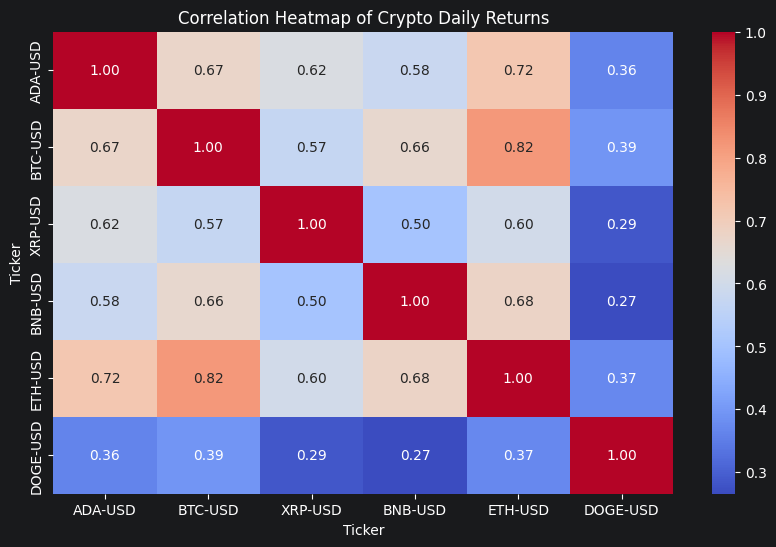

In [29]:
plt.figure(figsize=(10, 6))
sns.heatmap(return_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Crypto Daily Returns")
plt.show()

## 15. Pairplot of Daily Returns

### Request
Create a pairplot for selected crypto returns.

### Short explanation
Pairplots help us visually compare relationships between crypto returns. To keep it readable, we use a smaller set of major cryptos.

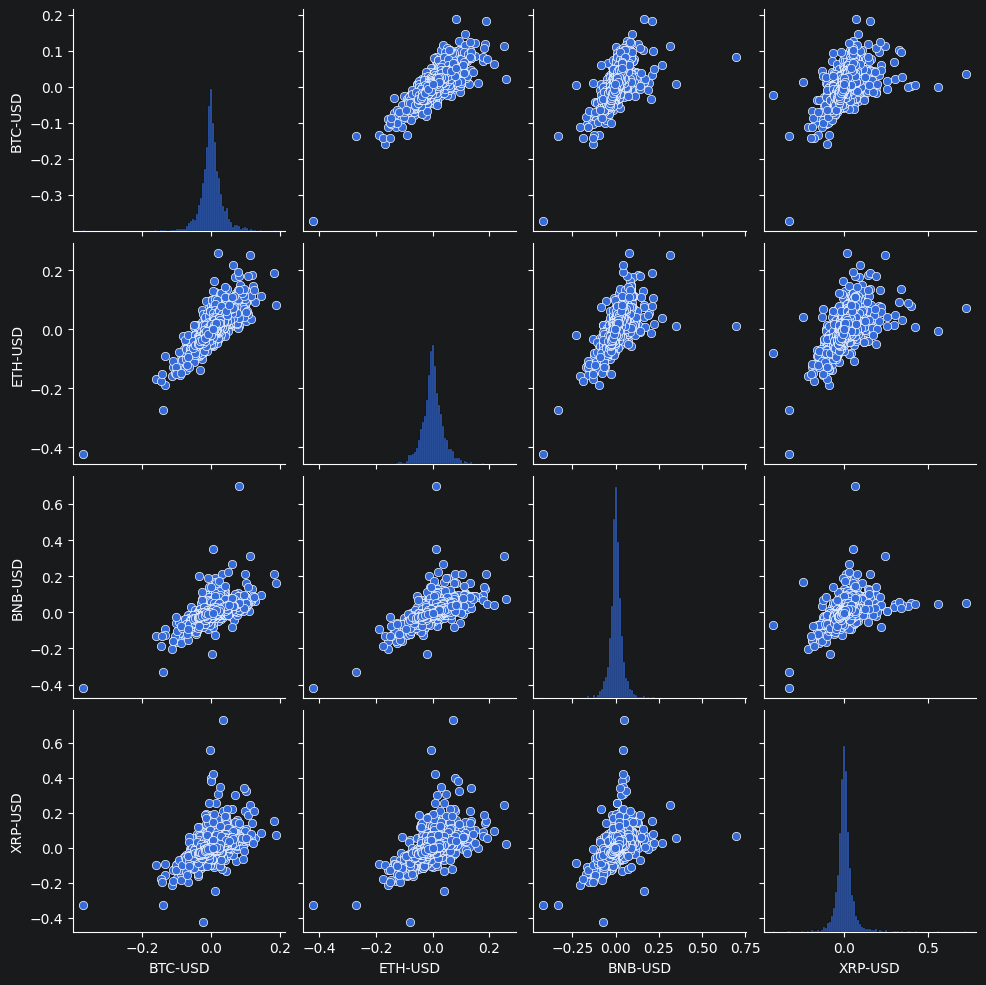

In [30]:
selected_returns = returns[["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD"]].dropna()

sns.pairplot(selected_returns)
plt.show()

## 16. Cumulative Return: If We Invested $1

### Request
Calculate how much $1 invested at the beginning would become over time.

### Short explanation
Cumulative return shows long-term investment growth including daily compounding.

$$(1+r_1)(1+r_2) \cdots (1+r_n)$$

In [31]:
cumulative_growth = (1 + returns).cumprod()

fig = px.line(
    cumulative_growth,
    x=cumulative_growth.index,
    y=cumulative_growth.columns,
    title="Growth of $1 Invested in Each Crypto",
    labels={"value": "Portfolio Value", "Date": "Date", "variable": "Crypto"}
)
fig.show()

## 17. Final Cumulative Return Ranking

### Request
Rank cryptocurrencies by final cumulative growth.

### Short explanation
This tells us which crypto performed best over the selected period based on price growth.

In [32]:
final_growth = cumulative_growth.iloc[-1].sort_values(ascending=False)

final_growth_df = final_growth.reset_index()
final_growth_df.columns = ["Crypto", "Final Value of $1"]
final_growth_df

,Crypto,Final Value of $1
0,DOGE-USD,52.382193
1,BNB-USD,44.931184
2,ETH-USD,17.249363
3,BTC-USD,10.597566
4,ADA-USD,7.357882
5,XRP-USD,7.097375


In [33]:
fig = px.bar(
    final_growth_df,
    x="Crypto",
    y="Final Value of $1",
    title="Final Value of $1 Invested by Crypto",
    text="Final Value of $1"
)
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.show()

# we used fig, so we can update texttemplate and textposition, just for decoraton...

## 18. Drawdown Analysis

### Request
Calculate the maximum drawdown for each crypto.

### Short explanation
Drawdown measures how far the price falls from its previous peak. It is one of the most important risk measures for investments.

In [34]:
running_max = close_prices_clean.cummax()
drawdown = (close_prices_clean / running_max) - 1

max_drawdown = drawdown.min().sort_values()
max_drawdown_df = max_drawdown.reset_index()
max_drawdown_df.columns = ["Crypto", "Max Drawdown"]

max_drawdown_df

,Crypto,Max Drawdown
0,DOGE-USD,-0.922585
1,ADA-USD,-0.920400
2,XRP-USD,-0.832490
3,ETH-USD,-0.793512
4,BTC-USD,-0.766346
5,BNB-USD,-0.708380


In [35]:
fig = px.bar(
    max_drawdown_df,
    x="Crypto",
    y="Max Drawdown",
    title="Maximum Drawdown by Crypto",
    text="Max Drawdown"
)
fig.update_traces(texttemplate="%{text:.2%}", textposition="outside")
fig.show()

## 19. Rolling Volatility

### Request
Calculate and plot 30-day rolling volatility.

### Short explanation
Rolling volatility shows how risk changes over time instead of giving only one value for the whole period.

In [36]:
rolling_volatility_30d = returns.rolling(window=30).std()

fig = px.line(
    rolling_volatility_30d,
    x=rolling_volatility_30d.index,
    y=rolling_volatility_30d.columns,
    title="30-Day Rolling Volatility",
    labels={"value": "30-Day Volatility", "Date": "Date", "variable": "Crypto"}
)
fig.show()

## 20. Monthly Average Returns

### Request
Calculate average monthly returns for each crypto.

### Short explanation
Daily data can be noisy. Monthly returns make it easier to see broader performance patterns.

In [37]:
monthly_prices = close_prices_clean.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna(how="all")

monthly_returns.head()

Ticker,ADA-USD,BTC-USD,XRP-USD,BNB-USD,ETH-USD,DOGE-USD
Date,,,,,,
2020-02-29,-0.116223,-0.080319,-0.033607,0.075400,0.220295,-0.066416
2020-03-31,-0.357334,-0.251278,-0.244947,-0.357560,-0.392338,-0.189709
2020-04-30,0.566000,0.344779,0.218821,0.353879,0.553982,0.348978
2020-05-31,0.553986,0.092683,-0.046320,0.000381,0.112589,0.045845
2020-06-30,0.117872,-0.034147,-0.133244,-0.095472,-0.020178,-0.091976


In [38]:
monthly_returns_mean = monthly_returns.mean().sort_values(ascending=False)
monthly_returns_mean_df = monthly_returns_mean.reset_index()
monthly_returns_mean_df.columns = ["Crypto", "Average Monthly Return"]

monthly_returns_mean_df

,Crypto,Average Monthly Return
0,DOGE-USD,0.198856
1,BNB-USD,0.097199
2,XRP-USD,0.094804
3,ADA-USD,0.087471
4,ETH-USD,0.062676
5,BTC-USD,0.044262


## 21. Volume Analysis

### Request
Find which cryptocurrencies had the highest average trading volume.

### Short explanation
Volume shows market activity. Higher volume usually means more liquidity and stronger trading interest.

In [39]:
volume_clean = volume.ffill()

avg_volume = volume_clean.mean().sort_values(ascending=False)
avg_volume_df = avg_volume.reset_index()
avg_volume_df.columns = ["Crypto", "Average Daily Volume"]

avg_volume_df

,Crypto,Average Daily Volume
0,BTC-USD,3.675844e+10
1,ETH-USD,1.883887e+10
2,XRP-USD,3.484654e+09
3,DOGE-USD,1.694934e+09
4,BNB-USD,1.613143e+09
5,ADA-USD,1.271882e+09


In [40]:
fig = px.bar(
    avg_volume_df,
    x="Crypto",
    y="Average Daily Volume",
    title="Average Daily Trading Volume by Crypto"
)
fig.show()

## 22. BTC Candlestick Chart

### Request
Create a candlestick chart for Bitcoin.

### Short explanation
Candlestick charts show Open, High, Low, and Close prices in one visualization. This is useful for market trend analysis.

In [41]:
# for more complicated graphs where we need full controll we use graph objects from plotly

btc_ohlc = crypto_data["BTC-USD"].copy()
btc_ohlc_2024 = btc_ohlc.loc["2024-01-01":"2024-12-31"]

fig = go.Figure(data=[
    go.Candlestick(
        x=btc_ohlc_2024.index,
        open=btc_ohlc_2024["Open"],
        high=btc_ohlc_2024["High"],
        low=btc_ohlc_2024["Low"],
        close=btc_ohlc_2024["Close"],
        name="BTC-USD"
    )
])

fig.update_layout(
    title="BTC Candlestick Chart - 2024",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    xaxis_rangeslider_visible=False
)

fig.show()

## 23. Risk vs Return Scatter Plot

### Request
Compare average return and volatility for each crypto.

### Short explanation
This plot helps us compare reward and risk. A crypto with higher return and lower volatility is generally more attractive.

In [42]:
risk_return = pd.DataFrame({
    "Crypto": returns.columns,
    "Average Daily Return": returns.mean().values,
    "Daily Volatility": returns.std().values,
    "Annualized Return Estimate": (returns.mean() * 365).values,
    "Annualized Volatility": (returns.std() * np.sqrt(365)).values
})

fig = px.scatter(
    risk_return,
    x="Annualized Volatility",
    y="Annualized Return Estimate",
    text="Crypto",
    title="Risk vs Return by Crypto",
    size="Daily Volatility",
    hover_data=["Average Daily Return", "Daily Volatility"]
)
fig.update_traces(textposition="top center")
fig.show()

risk_return.sort_values("Annualized Return Estimate", ascending=False)

,Crypto,Average Daily Return,Daily Volatility,Annualized Return Estimate,Annualized Volatility
5,DOGE-USD,0.004543,0.098784,1.658092,1.887265
3,BNB-USD,0.002590,0.043921,0.945219,0.839113
2,XRP-USD,0.002261,0.054512,0.825251,1.041444
0,ADA-USD,0.002206,0.052582,0.805013,1.004576
4,ETH-USD,0.002149,0.042505,0.784467,0.812055
1,BTC-USD,0.001534,0.031750,0.560053,0.606585


## 24. Simple Equal-Weight Crypto Portfolio

### Request
Create a simple portfolio where each crypto has equal weight.

### Short explanation
A portfolio combines multiple assets. Equal weighting means each crypto contributes the same percentage to the portfolio.

In [43]:
weights = np.repeat(1 / len(returns.columns), len(returns.columns))

portfolio_returns = returns.fillna(0).dot(weights)
portfolio_growth = (1 + portfolio_returns).cumprod()

fig = px.line(
    portfolio_growth,
    x=portfolio_growth.index,
    y=portfolio_growth.values,
    title="Growth of $1 in an Equal-Weight Crypto Portfolio",
    labels={"x": "Date", "y": "Portfolio Value"}
)
fig.show()

portfolio_summary = pd.DataFrame({
    "Metric": ["Average Daily Return", "Daily Volatility", "Annualized Return Estimate", "Annualized Volatility", "Final Value of $1"],
    "Value": [
        portfolio_returns.mean(),
        portfolio_returns.std(),
        portfolio_returns.mean() * 365,
        portfolio_returns.std() * np.sqrt(365),
        portfolio_growth.iloc[-1]
    ]
})

portfolio_summary

,Metric,Value
0,Average Daily Return,0.002547
1,Daily Volatility,0.040966
2,Annualized Return Estimate,0.929682
3,Annualized Volatility,0.782661
4,Final Value of $1,53.351849


## 25. Final Questions

Answer these based on your analysis:

1. Which cryptocurrency had the highest maximum closing price?
2. Which cryptocurrency had the highest final cumulative return?
3. Which cryptocurrency had the highest volatility?
4. Which cryptocurrency had the worst maximum drawdown?
5. Do BTC and ETH returns appear strongly correlated?
6. Does high average return always mean low risk?
7. Which crypto would you choose for a higher-risk strategy and why?
8. Which crypto would you choose for a more stable strategy and why?
9. What happened to BTC during 2024 based on the candlestick chart?
10. Is an equal-weight portfolio less risky than holding only one crypto?

## 26. Final Summary Template

Use this section to write your final conclusions.

In [44]:
# Example conclusion structure:

print("Final Summary")
print("-------------")
print("Best performer:", final_growth.idxmax())
print("Highest volatility:", risk_summary["Annualized Volatility"].idxmax())
print("Worst drawdown:", max_drawdown.idxmin())
print("Most correlated pair should be checked from the correlation heatmap.")

Final Summary
-------------
Best performer: DOGE-USD
Highest volatility: DOGE-USD
Worst drawdown: DOGE-USD
Most correlated pair should be checked from the correlation heatmap.
